In [4]:
%pip install pandas matplotlib seaborn nltk yfinance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download the specific tool for sentiment analysis
nltk.download('vader_lexicon')

# Load BOTH datasets
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
# Using the same ticker you used in Task 2 (AAPL)
import yfinance as yf
stock_df = yf.download('AAPL', start='2015-01-01', end='2021-01-01')

print("✅ Both datasets loaded and ready for the merger.")


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mekli\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Note: you may need to restart the kernel to use updated packages.


C:\Users\mekli\AppData\Local\Temp\ipykernel_21564\2881017764.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download('AAPL', start='2015-01-01', end='2021-01-01')
C:\Users\mekli\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

✅ Both datasets loaded and ready for the merger.


In [5]:
# Create the analyzer object
vader = SentimentIntensityAnalyzer()

# 1. Apply VADER to get the 'compound' score for each headline
# We use 'compound' because it's a single normalized score of overall sentiment
news_df['sentiment'] = news_df['headline'].apply(lambda x: vader.polarity_scores(x)['compound'])

# 2. Convert 'date' to a simple date format (YYYY-MM-DD) so it matches the stock data
# We handle the timezones first, then convert to date
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.date

# 3. Handle multiple headlines on the same day
# We take the average sentiment for all news that happened on a specific day
daily_sentiment = news_df.groupby('date')['sentiment'].mean()

print("✅ Sentiment scores calculated and averaged by day.")
print(f"Sample of daily sentiment scores:\n{daily_sentiment.head()}")

✅ Sentiment scores calculated and averaged by day.
Sample of daily sentiment scores:
date
2011-04-28    0.083333
2011-04-29    0.367550
2011-04-30    0.202300
2011-05-01    0.000000
2011-05-02    0.136444
Name: sentiment, dtype: float64


📊 THE RESULTS ARE IN!
Pearson Correlation between Sentiment and Stock Returns: 0.0721


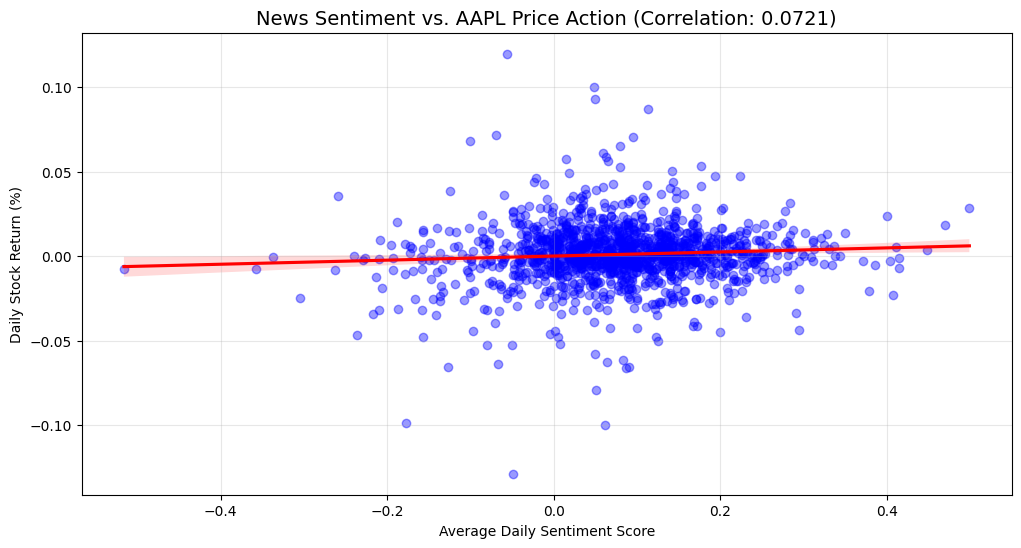

In [7]:
# 1. FLATTEN THE MULTI-INDEX (The fix for your MergeError)
# This turns ('Close', 'AAPL') into just 'Close'
if isinstance(stock_df.columns, pd.MultiIndex):
    stock_df.columns = stock_df.columns.get_level_values(0)

# 2. Calculate Daily Returns
stock_df['daily_return'] = stock_df['Close'].pct_change()

# 3. Prepare stock returns for merging
stock_returns = stock_df[['daily_return']].copy()
stock_returns.index = stock_returns.index.date

# 4. MERGE the averaged sentiment with the stock returns
# Now both have '1 level', so this will work!
combined_df = pd.merge(daily_sentiment, stock_returns, left_index=True, right_index=True, how='inner')

# 5. Run the Correlation Math
correlation = combined_df['sentiment'].corr(combined_df['daily_return'])

print(f"📊 THE RESULTS ARE IN!")
print(f"Pearson Correlation between Sentiment and Stock Returns: {correlation:.4f}")

# 6. Final Visualization
plt.figure(figsize=(12, 6))
sns.regplot(data=combined_df, x='sentiment', y='daily_return', 
            scatter_kws={'alpha':0.4, 'color':'blue'}, 
            line_kws={'color':'red'})
plt.title(f'News Sentiment vs. AAPL Price Action (Correlation: {correlation:.4f})', fontsize=14)
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')
plt.grid(True, alpha=0.3)
plt.show()